   location  nit_perc variety  Total(tons/ac)     chlgr     chlre       dvi  \
0        13        50    Nork       28.976340  9.002279  1.348789  0.379327   
1        14        50      RB       28.938475  7.686139  1.135524  0.340821   
2        15        50     New       28.948576  7.588182  1.111849  0.358106   
3        16       150     New       25.239486  7.725139  1.122824  0.363922   
4        17       150      RB       21.459876  7.456070  1.081178  0.328136   

        evi      evi2     gndvi  ...     msavi       msr      ndvi     osavi  \
0  0.642753  0.608973  0.813741  ...  0.599423  2.958103  0.801219  0.691913   
1  0.590405  0.559537  0.789483  ...  0.550331  2.743764  0.777706  0.658416   
2  0.615513  0.581109  0.787615  ...  0.571565  2.812644  0.786773  0.665069   
3  0.623596  0.588967  0.790694  ...  0.579762  2.839168  0.789791  0.670377   
4  0.574173  0.543206  0.784241  ...  0.533725  2.659230  0.768338  0.650604   

        pvi      savi      savi2         sr 

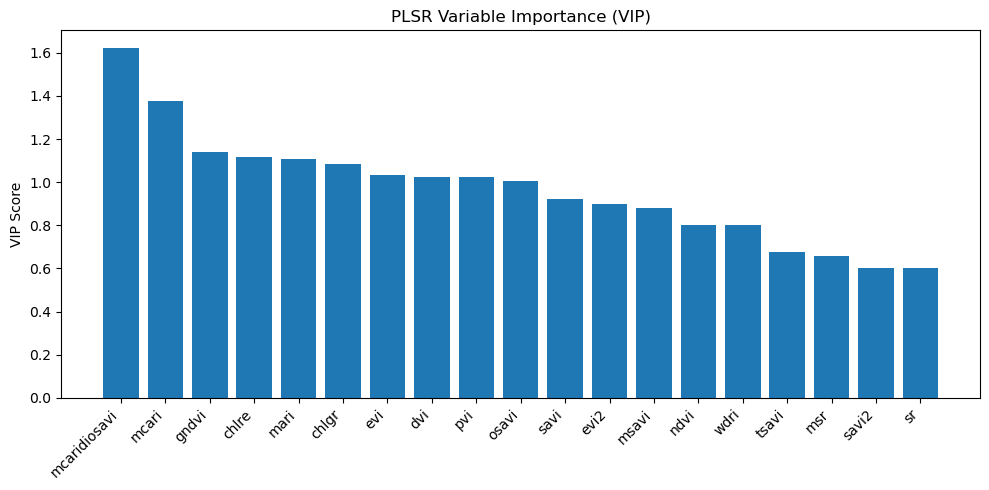

In [ ]:
#   “Copyright (C) 2024 Mississippi State University.
 
#    This program is free software: you can redistribute it and/or modify
#    it under the terms of the GNU General Public License as published by
#    the Free Software Foundation, either version 3 of the License, or
#    (at your option) any later version.
 
#    This program is distributed in the hope that it will be useful,
#    but WITHOUT ANY WARRANTY; without even the implied warranty of
#    MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
#    GNU General Public License for more details.
 
#    You should have received a copy of the GNU General Public License
#    along with this program.  If not, see <https://www.gnu.org/licenses/>.
 
# To inquire about relicensing, accessing more training data, collaborating with the author, or any general inquiry about the software, please contact Mississippi State University’s Office of Technology Management at otm@msstate.edu, (662) 325-9263.”


# Dependency Libraries
import pandas as pd
import numpy as np
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt


# INPUT FILE

file_path = r"C:\Users\Say70\OneDrive - Mississippi State University\Desktop\UGA talk\Yield Data\Yield Data_vs_6_10_2020_VIs.xlsx"

df = pd.read_excel(file_path)

print(df.head())
print(df.columns)


# VARIABLES

variable_names = [
    'ndvi','gndvi','dvi','evi','evi2','mari','chlre','chlgr','savi','savi2',
    'msavi','osavi','tsavi','msr','mcari','mcaridiosavi','pvi','sr','wdri'
]

target_name = 'Total(tons/ac)'  


# CLEAN DATA

df = df.dropna()

X = df[variable_names].values
y = df[target_name].values


# STANDARDIZE

scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_std = scaler_x.fit_transform(X)
y_std = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()


# GRID SEARCH (find optimal components)

param_grid = {'n_components': list(range(1, 6))}

pls = PLSRegression()

grid = GridSearchCV(pls, param_grid, scoring='neg_mean_squared_error', cv=5)
grid.fit(X_std, y_std)

best_n = grid.best_params_['n_components']
print("Best n_components:", best_n)


# FINAL MODEL

pls_model = PLSRegression(n_components=best_n)
pls_model.fit(X_std, y_std)


# VIP FUNCTION

def calculate_vip(model, X, y):
    T = model.x_scores_
    W = model.x_weights_
    Q = model.y_loadings_

    p = W.shape[0]
    h = W.shape[1]

    s = np.diag(T.T @ T @ Q.T @ Q).reshape(h, -1)
    total_s = np.sum(s)

    vip = np.zeros(p)

    for i in range(p):
        weight = np.array([(W[i, j] ** 2) * s[j] for j in range(h)])
        vip[i] = np.sqrt(p * np.sum(weight) / total_s)

    return vip


# CALCULATE VIP

vip_scores = calculate_vip(pls_model, X_std, y_std)


# CREATE RESULT TABLE

results = pd.DataFrame({
    'Variable': variable_names,
    'VIP': vip_scores,
    'Coefficient': pls_model.coef_.flatten()
})

# Sort by importance
results = results.sort_values(by='VIP', ascending=False)

print("\nFeature Ranking:")
print(results)


# SAVE RESULTS

output_path = r"C:\Users\Say70\OneDrive - Mississippi State University\Desktop\UGA talk\Yield Data\PLSR_VIP_Ranking.xlsx"
results.to_excel(output_path, index=False)

print("\nSaved VIP ranking to:", output_path)

# PLOT VIP

plt.figure(figsize=(10,5))
plt.bar(results['Variable'], results['VIP'])
plt.xticks(rotation=45, ha='right')
plt.ylabel("VIP Score")
plt.title("PLSR Variable Importance (VIP)")
plt.tight_layout()
plt.show()